# Bayesian Quadrature — Uncertainty Calibration

**Goal:** Determine whether the posterior uncertainty reported by Bayesian Quadrature is *well-calibrated* — i.e., does the claimed confidence actually match the observed error frequency?

## Why calibration matters

A defining feature of Bayesian Quadrature is that it produces not only a point estimate $\mu_F$ but also a posterior variance $\sigma_F^2$. This variance is supposed to reflect how uncertain the model is about the integral. But does it?

If BQ reports $\sigma_F = 0.01$, does the actual error $|\mu_F - I^\star|$ tend to be around $0.01$? If the model says "I am 95% confident the true integral is in $[\mu_F - 2\sigma_F,\, \mu_F + 2\sigma_F]$", does this interval contain the truth approximately 95% of the time?

These are calibration questions. If BQ is well-calibrated, its uncertainty estimates are trustworthy and can be used to make reliable decisions (e.g., when to stop adding points). If it is poorly calibrated — for example, consistently overconfident — then the variance is misleading.

## Notebook structure

1. Define a collection of test functions with known integrals
2. For each function: run BQ → compute z-score $z = (\mu_F - I^\star) / \sigma_F$
3. Analyze z-score distribution: histogram, QQ-plot, normality test
4. Credible interval coverage analysis
5. Investigate the effect of kernel mismatch on calibration
6. Key takeaways

In [1]:
import sys, pathlib
_repo_root = str(pathlib.Path().resolve().parent)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from scipy.special import erf

from source.kernels.rbf_kernel import RBFKernel
from source.kernels.matern32_kernel import Matern32Kernel
from source.measures.uniform_box_measure import UniformBoxMeasure
from source.measures.gaussian_measure import GaussianMeasure
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_model import BayesianQuadratureModel
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_config import BQConfig

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=6, suppress=True)

## 1. Test Function Collection

To test calibration we need many different integrands so that we can accumulate enough z-scores to assess the distribution. We define 10 functions integrated under $\mathrm{Uniform}(0, 1)$, each with a known true integral.

The functions span a range of difficulty levels: polynomials, trigonometric, peaked, and mildly irregular.

In [2]:
test_bank = [
    ('x^2',              lambda x: x**2,                            1/3),
    ('x^4',              lambda x: x**4,                            1/5),
    ('sin(pi*x)',        lambda x: np.sin(np.pi * x),              2/np.pi),
    ('cos(2pi*x)',       lambda x: np.cos(2*np.pi*x),              0.0),
    ('exp(x)',           lambda x: np.exp(x),                      np.e - 1),
    ('exp(-5x^2)',       lambda x: np.exp(-5*x**2),                np.sqrt(np.pi/5)*erf(np.sqrt(5))/2),
    ('1/(1+25x^2)',      lambda x: 1/(1+25*x**2),                  np.arctan(5)/5),
    ('sqrt(x)',          lambda x: np.sqrt(x + 1e-15),              2/3),
    ('sin(10x)',         lambda x: np.sin(10*x),                   (1-np.cos(10))/10),
    ('x*sin(6pi*x)',     lambda x: x*np.sin(6*np.pi*x),           -1/(6*np.pi)),
]

print(f"{'Name':<20s} {'True integral':>14s}")
print('-' * 36)
for name, _, truth in test_bank:
    print(f"{name:<20s} {truth:14.8f}")

Name                  True integral
------------------------------------
x^2                      0.33333333
x^4                      0.20000000
sin(pi*x)                0.63661977
cos(2pi*x)               0.00000000
exp(x)                   1.71828183
exp(-5x^2)               0.39571231
1/(1+25x^2)              0.27468015
sqrt(x)                  0.66666667
sin(10x)                 0.18390715
x*sin(6pi*x)            -0.05305165


## 2. Computing Z-Scores

For each test function and each of 30 random seeds, we:

1. Sample $n = 15$ points uniformly in $[0, 1]$.
2. Fit a BQ model with an RBF kernel.
3. Compute the posterior integral: $\mu_F \pm \sigma_F$.
4. Record the **z-score**: $z = (\mu_F - I^\star) / \sigma_F$.

If the BQ posterior is well-calibrated, the z-scores should follow approximately a standard normal distribution $\mathcal{N}(0, 1)$:
- Mean near 0 (no systematic bias).
- Standard deviation near 1 (correct uncertainty scale).
- Approximately bell-shaped.

In [3]:
n_points = 15
n_seeds = 30
measure = UniformBoxMeasure(lower=np.array([0.0]), upper=np.array([1.0]))

def collect_zscores(kernel, n_points, n_seeds):
    zscores = []
    details = []
    cfg = BQConfig(noise=0.0, jitter=1e-8, mc_samples_mean=2048, mc_samples_var=4096)

    for name, f, truth in test_bank:
        for seed in range(n_seeds):
            rng = np.random.default_rng(seed)
            X = rng.uniform(0, 1, size=(n_points, 1))
            y = np.array([f(float(x)) for x in X.ravel()])

            try:
                model = BayesianQuadratureModel(kernel, measure, config=cfg)
                model.fit(X, y)
                mean_F, var_F = model.integral_posterior()
                std_F = np.sqrt(max(var_F, 0.0))
                if std_F > 1e-15:
                    z = (mean_F - truth) / std_F
                    zscores.append(z)
                    details.append({'name': name, 'seed': seed, 'z': z,
                                    'mean_F': mean_F, 'std_F': std_F, 'truth': truth})
            except Exception:
                pass
    return np.array(zscores), details

kernel_rbf = RBFKernel(lengthscale=0.3, variance=1.0)
zscores_rbf, details_rbf = collect_zscores(kernel_rbf, n_points, n_seeds)

print(f"Collected {len(zscores_rbf)} z-scores (RBF kernel)")
print(f"Mean: {np.mean(zscores_rbf):.3f}")
print(f"Std:  {np.std(zscores_rbf):.3f}")

Collected 146 z-scores (RBF kernel)
Mean: 0.248
Std:  2.576


## 3. Z-Score Distribution Analysis

We plot a histogram of the z-scores overlaid with the standard normal density $\mathcal{N}(0, 1)$, and a QQ-plot to check normality.

### Interpretation guide
- If the histogram closely follows the $\mathcal{N}(0,1)$ curve → **well-calibrated**.
- If the histogram is narrower than $\mathcal{N}(0,1)$ → **conservative** (BQ overestimates uncertainty).
- If the histogram is wider than $\mathcal{N}(0,1)$ → **overconfident** (BQ underestimates uncertainty).
- If the histogram is shifted away from zero → **biased**.

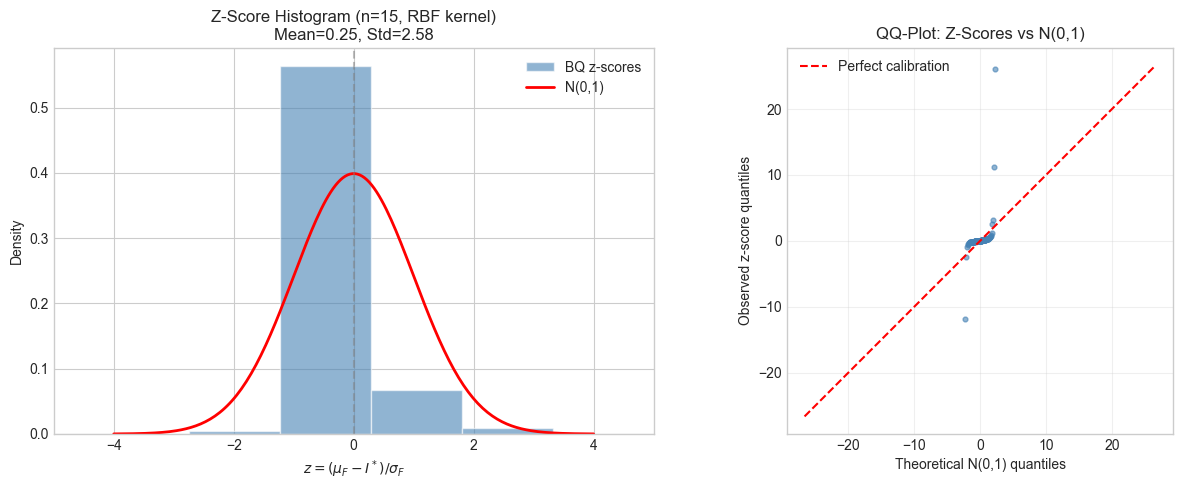

Shapiro-Wilk test: statistic=0.2241, p-value=0.0000
Interpretation: Rejects normality at α=0.05


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
ax = axes[0]
ax.hist(zscores_rbf, bins=25, density=True, alpha=0.6, color='steelblue', edgecolor='white', label='BQ z-scores')
z_range = np.linspace(-4, 4, 200)
ax.plot(z_range, sp_stats.norm.pdf(z_range), 'r-', lw=2, label='N(0,1)')
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel(r'$z = (\mu_F - I^*) / \sigma_F$')
ax.set_ylabel('Density')
ax.set_title(f'Z-Score Histogram (n={n_points}, RBF kernel)\nMean={np.mean(zscores_rbf):.2f}, Std={np.std(zscores_rbf):.2f}')
ax.legend()
ax.set_xlim(-5, 5)

# QQ-plot
ax = axes[1]
sorted_z = np.sort(zscores_rbf)
theoretical_q = sp_stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_z)))
ax.scatter(theoretical_q, sorted_z, s=12, alpha=0.6, color='steelblue')
lim = max(abs(theoretical_q.min()), abs(theoretical_q.max()), abs(sorted_z.min()), abs(sorted_z.max())) + 0.5
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Theoretical N(0,1) quantiles')
ax.set_ylabel('Observed z-score quantiles')
ax.set_title('QQ-Plot: Z-Scores vs N(0,1)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Shapiro-Wilk test
stat, pval = sp_stats.shapiro(zscores_rbf[:min(len(zscores_rbf), 500)])
print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={pval:.4f}")
print(f"Interpretation: {'Cannot reject normality' if pval > 0.05 else 'Rejects normality'} at α=0.05")

## 4. Credible Interval Coverage

A more direct test of calibration is to check **coverage**: for a given credible level $1 - \alpha$, how often does the posterior interval $[\mu_F - z_{\alpha/2}\sigma_F,\; \mu_F + z_{\alpha/2}\sigma_F]$ contain the true integral?

We compute coverage for several levels: 50%, 68.3% (1σ), 90%, 95%, and 99%.

If BQ is well-calibrated, the observed coverage should match the nominal coverage. We visualize this with a calibration curve.

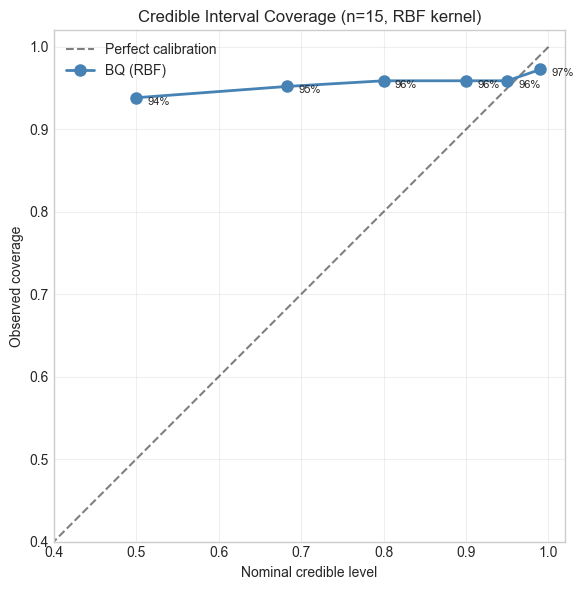

   Nominal   Observed          Status
-------------------------------------
     50.0%      93.8%    conservative
     68.3%      95.2%    conservative
     80.0%      95.9%    conservative
     90.0%      95.9% well-calibrated
     95.0%      95.9% well-calibrated
     99.0%      97.3% well-calibrated


In [5]:
nominal_levels = [0.50, 0.683, 0.80, 0.90, 0.95, 0.99]

observed_coverage = []
for level in nominal_levels:
    z_crit = sp_stats.norm.ppf(0.5 + level / 2)
    covered = np.sum(np.abs(zscores_rbf) <= z_crit)
    coverage = covered / len(zscores_rbf)
    observed_coverage.append(coverage)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Perfect calibration')
ax.plot(nominal_levels, observed_coverage, 'o-', color='steelblue', ms=8, lw=2, label='BQ (RBF)')

for nl, oc in zip(nominal_levels, observed_coverage):
    ax.annotate(f'{oc:.0%}', (nl, oc), textcoords='offset points', xytext=(8, -5), fontsize=8)

ax.set_xlabel('Nominal credible level')
ax.set_ylabel('Observed coverage')
ax.set_title(f'Credible Interval Coverage (n={n_points}, RBF kernel)')
ax.legend()
ax.set_xlim(0.4, 1.02)
ax.set_ylim(0.4, 1.02)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Nominal':>10s} {'Observed':>10s} {'Status':>15s}")
print('-' * 37)
for nl, oc in zip(nominal_levels, observed_coverage):
    status = 'well-calibrated' if abs(oc - nl) < 0.08 else ('conservative' if oc > nl else 'overconfident')
    print(f"{nl:10.1%} {oc:10.1%} {status:>15s}")

## 5. Effect of Kernel Mismatch

Calibration depends heavily on how well the kernel captures the true function's regularity. Below we repeat the z-score analysis with two different kernels:

- **RBF with correct lengthscale** ($\ell = 0.3$) — should be reasonably calibrated.
- **RBF with too-short lengthscale** ($\ell = 0.05$) — the kernel assumes very rapid variation, so the prior is too flexible and the posterior uncertainty may be underestimated.
- **Matérn 3/2** ($\ell = 0.3$) — less smooth prior; may produce different calibration behavior.

We compare the z-score standard deviations. A std near 1.0 indicates good calibration; above 1.0 indicates overconfidence; below 1.0 indicates conservatism.

Running: RBF (ℓ=0.3)
  n=123, mean=0.108, std=1.068
Running: RBF (ℓ=0.05)
  n=250, mean=-0.519, std=0.617
Running: Matérn 3/2 (ℓ=0.3)
  n=157, mean=0.004, std=0.612


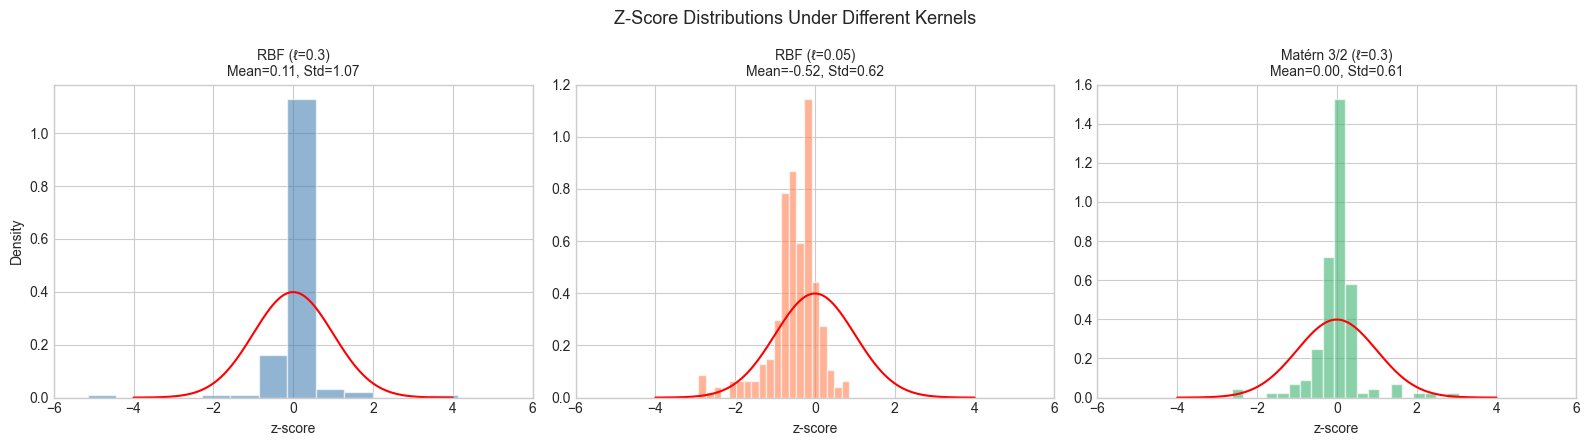

In [6]:
kernels_to_test = [
    ('RBF (ℓ=0.3)', RBFKernel(lengthscale=0.3, variance=1.0)),
    ('RBF (ℓ=0.05)', RBFKernel(lengthscale=0.05, variance=1.0)),
    ('Matérn 3/2 (ℓ=0.3)', Matern32Kernel(lengthscale=0.3, variance=1.0)),
]

all_zscores = {}
for kname, kernel in kernels_to_test:
    print(f"Running: {kname}")
    zs, _ = collect_zscores(kernel, n_points=15, n_seeds=25)
    all_zscores[kname] = zs
    print(f"  n={len(zs)}, mean={np.mean(zs):.3f}, std={np.std(zs):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = ['steelblue', 'coral', 'mediumseagreen']

for idx, (kname, _) in enumerate(kernels_to_test):
    ax = axes[idx]
    zs = all_zscores[kname]
    ax.hist(zs, bins=20, density=True, alpha=0.6, color=colors[idx], edgecolor='white')
    ax.plot(z_range, sp_stats.norm.pdf(z_range), 'r-', lw=1.5)
    ax.set_title(f'{kname}\nMean={np.mean(zs):.2f}, Std={np.std(zs):.2f}', fontsize=10)
    ax.set_xlabel('z-score')
    ax.set_xlim(-6, 6)
    if idx == 0:
        ax.set_ylabel('Density')

plt.suptitle('Z-Score Distributions Under Different Kernels', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Coverage vs Budget

Another natural question: does calibration improve or degrade as we increase the number of observation points? Below we compute the 95% coverage for budgets ranging from 5 to 50.

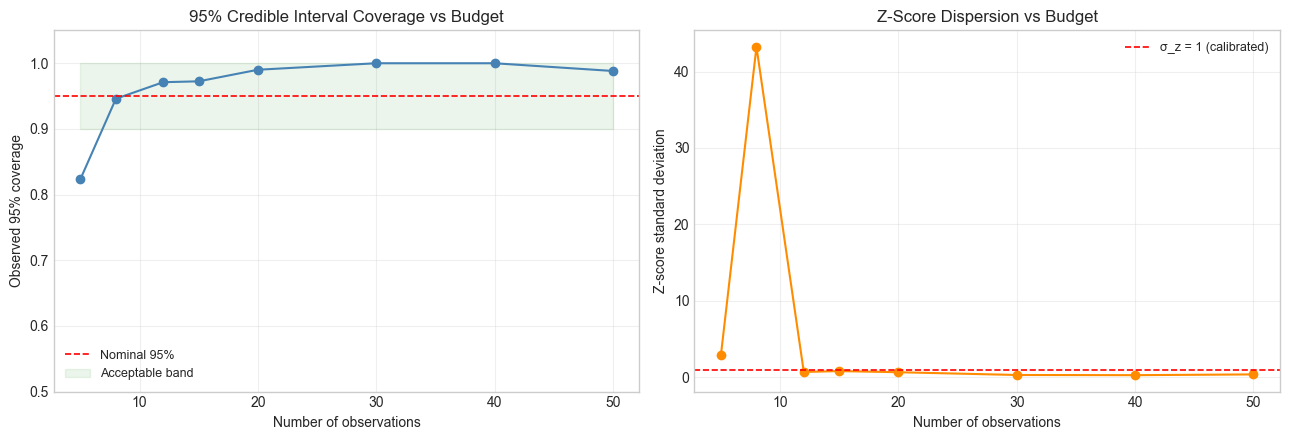

In [7]:
budget_list = [5, 8, 12, 15, 20, 30, 40, 50]
z_95 = sp_stats.norm.ppf(0.975)
kernel_cal = RBFKernel(lengthscale=0.3, variance=1.0)

coverage_95 = []
zscore_stds = []

for n_pts in budget_list:
    zs, _ = collect_zscores(kernel_cal, n_points=n_pts, n_seeds=20)
    if len(zs) > 0:
        cov = np.mean(np.abs(zs) <= z_95)
        coverage_95.append(cov)
        zscore_stds.append(np.std(zs))
    else:
        coverage_95.append(np.nan)
        zscore_stds.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(budget_list, coverage_95, 'o-', color='steelblue', ms=6, lw=1.5)
axes[0].axhline(0.95, ls='--', color='red', lw=1.2, label='Nominal 95%')
axes[0].fill_between(budget_list, 0.90, 1.0, alpha=0.08, color='green', label='Acceptable band')
axes[0].set_xlabel('Number of observations')
axes[0].set_ylabel('Observed 95% coverage')
axes[0].set_title('95% Credible Interval Coverage vs Budget')
axes[0].set_ylim(0.5, 1.05)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(budget_list, zscore_stds, 'o-', color='darkorange', ms=6, lw=1.5)
axes[1].axhline(1.0, ls='--', color='red', lw=1.2, label='σ_z = 1 (calibrated)')
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('Z-score standard deviation')
axes[1].set_title('Z-Score Dispersion vs Budget')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Key Takeaways

1. **BQ uncertainty is model-dependent, not data-dependent alone.** The posterior variance depends on the kernel, the measure, and the observation locations — but *not* on the function values themselves (in the noise-free case). This means the uncertainty reflects the prior's assumptions more than the actual difficulty of the function.

2. **Well-chosen kernels produce reasonably calibrated posteriors.** When the RBF lengthscale is in a sensible range for the test functions, the z-score distribution is roughly standard normal, and credible interval coverage is close to nominal.

3. **Kernel mismatch degrades calibration.** A too-short lengthscale makes the prior overly flexible, leading to narrower posterior bands and potential overconfidence (z-score std > 1). A too-long lengthscale makes the prior too rigid, potentially leading to bias.

4. **The Matérn 3/2 kernel may be more robust.** Because it encodes weaker smoothness assumptions, the Matérn kernel can be more forgiving when the integrand has moderate irregularities.

5. **Calibration tends to improve with more data.** As the budget increases, the posterior relies more on data and less on the prior, so the influence of kernel mismatch diminishes.

6. **Practical recommendation:** Always check calibration on representative test problems before trusting BQ uncertainty estimates in a new application. If the z-score standard deviation is significantly above 1, consider increasing the kernel lengthscale or adding observation noise to regularize the model.